# Market Making via Reinforcement Learning — on order-by-order (MBO) data
**Spooner, Fearnley, Savani & Koukorinis (2018)** | *AAMAS 2018* | arXiv:1804.04216

---
This notebook adapts the methodology of Spooner et al. (2018) to **Databento CME MBO**
(market-by-order) data for CME equity-index futures (front-month **ES**). It reconstructs
a limit order book order-by-order, simulates a market-making agent against the historical
flow, and trains a **temporal-difference RL** agent — *tile coding + a linear combination
of tile codings (LCTC)*, with **SARSA(λ)** and an **asymmetrically-dampened reward**.
It is *not* deep learning; the paper deliberately uses lightweight linear TD methods.

### The key upgrade over the paper
The paper only had *aggregated* market-by-price depth, so it had to **approximate** the
agent's queue position (assume cancellations are uniformly distributed). MBO carries every
order's `order_id`, so we track the **exact FIFO queue position** — and we implement the
paper's approximation too, to measure how much it distorts fills.

> **Deviations from the paper (futures vs. European equities).**
> - Instruments: CME **ES/MES** futures on a single venue, not 10 cash equities on 5 venues.
> - Data span: ~38 RTH sessions (May–Jun 2025), not 8 months — the train/test split is smaller.
> - Sizes: `order_size = 1` contract and inventory bounds ±50, not 1000 shares / ±10000.
> - The methodology (action space, rewards, tile-coding/LCTC, SARSA(λ)) is carried over verbatim.


## 1. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _find_repo_root() -> Path:
    for path in (Path.cwd(), *Path.cwd().parents):
        if (path / "pyproject.toml").is_file():
            return path
    raise FileNotFoundError("repo root (pyproject.toml) not found")

REPO = _find_repo_root()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 11})

from algo_mm.rl import (
    ASK, BID, PRICE_SCALE, CachedSession, OrderBook, replay_session,
    MarketMakingEnv, EnvConfig, AgentConfig, TrainConfig, STATE_FEATURE_NAMES,
    MARKET_FEATURE_NAMES, TDAgent, compute_reward, FixedPolicy, RandomPolicy,
    run_episode, evaluate_policy, make_queue, train, discover_sessions,
)
from algo_mm.rl.agent_orders import ExactFIFOQueue, UniformCancelQueue, AgentOrderBook

CACHE = REPO / "outputs" / "rl_cache" / "mbo"
sessions = discover_sessions(CACHE)
print(f"{len(sessions)} cached sessions: {sessions[0].parent.name} {sessions[0].stem} … "
      f"{sessions[-1].parent.name} {sessions[-1].stem}")
SESSION_PATH = sessions[0]


38 cached sessions: ESM5 2025-05-07 … ESU5 2025-06-27


## 2. The data-driven simulator (§3)

We reconstruct the **order book directly from historical MBO events**. On CME MDP3 (verified
against the data), the book is mutated only by **Add / Cancel / Modify / Clear**; a trade emits
a `T` print plus per-order `F` fills plus the matching `C` that removes the resting order, so
`T`/`F` are *trade-flow* signals. The book is only guaranteed uncrossed at `F_LAST` packet
boundaries.

Mid-price and spread (best quotes $p^b_1, p^a_1$):
$$m = \tfrac{1}{2}(p^b_1 + p^a_1), \qquad s = p^a_1 - p^b_1.$$

> **Assumptions** — Agent orders do **not** impact the market (reconstruction is fixed history);
> valid because `order_size` ≪ market volume.
> **Strengths** — Full order-by-order fidelity; nanosecond timestamps; exact trade flow.
> **Weaknesses** — No counterfactual market response to the agent; a single session per episode.


200,000 events replayed · 8,044 trades · book uncrossed at every F_LAST boundary


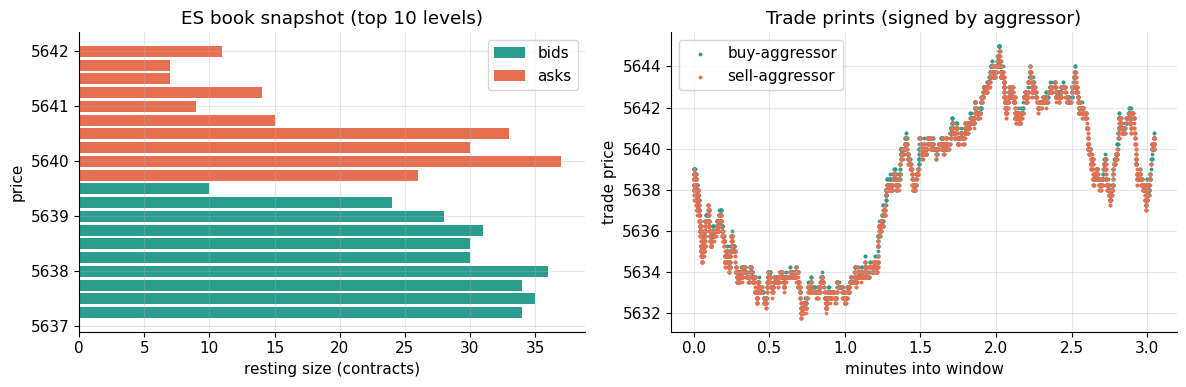

In [2]:
# Reconstruct the book over the first slice of the session and take a depth snapshot.
full = CachedSession.from_parquet(SESSION_PATH)
N = min(len(full), 200_000)
sub = CachedSession(*[getattr(full, n)[:N] for n in
      ("ts_event","action","side","price","size","order_id","sequence","flags")])

snapshot = {}
def grab(i, ts, book):
    if i > N // 2 and not snapshot:
        b, a = book.depth(10)
        snapshot["bids"] = [(p * PRICE_SCALE, s) for p, s in b]
        snapshot["asks"] = [(p * PRICE_SCALE, s) for p, s in a]
res = replay_session(sub, collect_trades=True, on_snapshot=grab)
trades = res["trades"]
print(f"{N:,} events replayed · {len(trades):,} trades · book uncrossed at every F_LAST boundary")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4))
bp = np.array(snapshot["bids"]); ap = np.array(snapshot["asks"])
axL.barh(bp[:,0], bp[:,1], height=0.2, color="#2a9d8f", label="bids")
axL.barh(ap[:,0], ap[:,1], height=0.2, color="#e76f51", label="asks")
axL.set(xlabel="resting size (contracts)", ylabel="price", title="ES book snapshot (top 10 levels)")
axL.legend()

tp = np.array([(t.ts_event, t.price * PRICE_SCALE, t.aggressor_side) for t in trades])
t0 = tp[:,0].min(); mins = (tp[:,0]-t0)/6e10
buy = tp[:,2] > 0
axR.scatter(mins[buy], tp[buy,1], s=3, c="#2a9d8f", label="buy-aggressor")
axR.scatter(mins[~buy], tp[~buy,1], s=3, c="#e76f51", label="sell-aggressor")
axR.set(xlabel="minutes into window", ylabel="trade price", title="Trade prints (signed by aggressor)")
axR.legend(); plt.tight_layout(); plt.show()


## 3. Exact vs. approximate queue position — the MBO advantage

When a trade arrives at the agent's price, the agent fills only once the volume **ahead** of it
in the FIFO queue is consumed.

**Exact (MBO).** With `order_id` we compute the true volume ahead from the reconstructed book:
$$\text{fill} = \max\!\big(0,\; \text{trade size} - \text{volume ahead}\big).$$

**Uniform-cancel (paper's approximation for aggregated depth).** Executions consume the queue
from the front (known from trades), but a cancellation of size $\delta$ has *unknown* position and
is assumed uniform, reducing the volume ahead by
$$\delta \cdot \frac{\text{ahead}}{\text{ahead}+\text{behind}}.$$

> **Strengths (exact)** — No queue-position guess; correct handling of cancels ahead of the agent.
> **Weaknesses (uniform)** — Systematically mis-estimates fills whenever there is volume behind the
> agent; the chart below quantifies the gap on a fixed passive strategy.


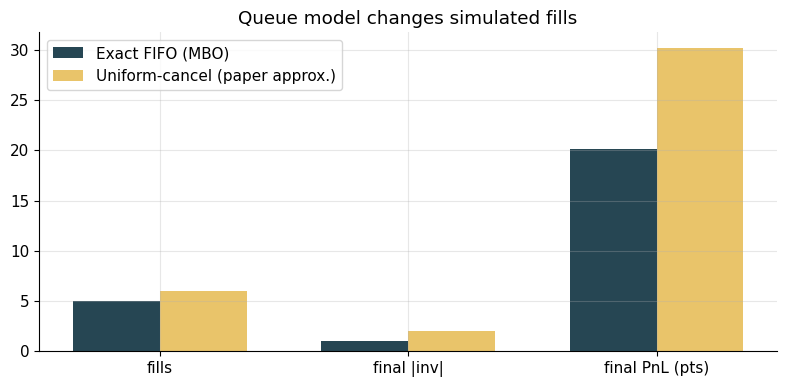

Exact:   fills=5  PnL=20.12
Uniform: fills=6  PnL=30.25


In [3]:
# Same fixed passive strategy under both queue models; compare fills / inventory / PnL.
def run_fixed(queue_cls, cap=6000):
    env = MarketMakingEnv(full, EnvConfig(order_size=1, max_inventory=30, min_inventory=-30,
            reward="pnl", max_interval_ns=int(1e9)), queue_model=queue_cls())
    r = run_episode(env, FixedPolicy(2), max_steps=cap)
    return r

ex = run_fixed(ExactFIFOQueue); un = run_fixed(UniformCancelQueue)
labels = ["fills", "final |inv|", "final PnL (pts)"]
exact_vals = [ex.n_fills, abs(ex.inventory[-1]), ex.equity[-1]]
unif_vals  = [un.n_fills, abs(un.inventory[-1]), un.equity[-1]]
x = np.arange(len(labels)); w = 0.35
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(x-w/2, exact_vals, w, label="Exact FIFO (MBO)", color="#264653")
ax.bar(x+w/2, unif_vals, w, label="Uniform-cancel (paper approx.)", color="#e9c46a")
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_title("Queue model changes simulated fills")
ax.legend(); plt.tight_layout(); plt.show()
print(f"Exact:   fills={ex.n_fills}  PnL={ex.equity[-1]:.2f}")
print(f"Uniform: fills={un.n_fills}  PnL={un.equity[-1]:.2f}")


## 4. The agent's action space (Table 1) and quote pricing (Eqs. 1–2)

At each decision epoch the agent picks one of **ten** actions: nine $(\theta^a,\theta^b)$
quoting-distance pairs, or action 9 = a market order that clears inventory. Quotes are placed at
integer multiples of a **spread scale** (a moving average of the market half-spread, rounded to
whole ticks):
$$p^a = m + \theta^a\,\text{Spread}, \qquad p^b = m - \theta^b\,\text{Spread}. \tag{1–2}$$
Small $\theta$ ⇒ tight quotes (fill often, capture little); large $\theta$ ⇒ wide quotes; asymmetric
$\theta^a\neq\theta^b$ ⇒ skew.


,theta_ask,theta_bid,kind
action,,,
0,1,1,symmetric
1,2,2,symmetric
2,3,3,symmetric
3,4,4,symmetric
4,5,5,symmetric
5,1,3,skewed
6,3,1,skewed
7,2,5,skewed
8,5,2,skewed


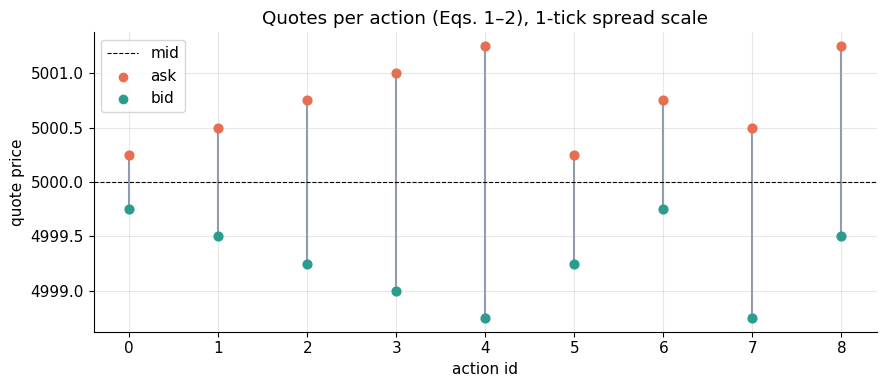

In [4]:
from algo_mm.rl.config import ACTION_THETA_ASK, ACTION_THETA_BID
tbl = pd.DataFrame({"action": range(9), "theta_ask": ACTION_THETA_ASK, "theta_bid": ACTION_THETA_BID})
display(tbl.assign(kind=["symmetric"]*5 + ["skewed"]*4).set_index("action"))

mid, scale = 5000.0, 0.25  # illustrate quote ladder for one tick spread-scale
fig, ax = plt.subplots(figsize=(9,4))
for a in range(9):
    pa = mid + ACTION_THETA_ASK[a]*scale; pb = mid - ACTION_THETA_BID[a]*scale
    ax.plot([a,a],[pb,pa], color="#8d99ae", zorder=1)
    ax.scatter(a, pa, c="#e76f51", s=40, zorder=2); ax.scatter(a, pb, c="#2a9d8f", s=40, zorder=2)
ax.axhline(mid, ls="--", c="k", lw=0.8, label="mid")
ax.scatter([],[],c="#e76f51",label="ask"); ax.scatter([],[],c="#2a9d8f",label="bid")
ax.set(xlabel="action id", ylabel="quote price", title="Quotes per action (Eqs. 1–2), 1-tick spread scale")
ax.legend(); plt.tight_layout(); plt.show()


## 5. Reward functions (Eqs. 3–6)

Per interval the agent's executions produce spread capture relative to the mid, $\psi_a+\psi_b$
(Eq. 3), plus a mark-to-market term on carried inventory:
$$\Psi = \underbrace{\psi_a+\psi_b}_{\text{spread capture}} + \underbrace{\text{Inv}\cdot\Delta m}_{\text{speculation}}.$$
The three studied rewards damp the speculation term differently:
$$r_{\text{PnL}}=\Psi;\quad r_{\text{sym}}=\Psi-\eta\,\text{Inv}\,\Delta m;\quad
  r_{\text{asym}}=\Psi-\max(0,\eta\,\text{Inv}\,\Delta m). \tag{4–6}$$

> **Why asymmetric damping (the paper's key result).** It removes the *upside* of speculation while
> keeping the *downside*, so spread capture dominates and the agent converges to small, neutral
> inventories. The plot shows reward vs. the inventory term for a fixed spread capture.


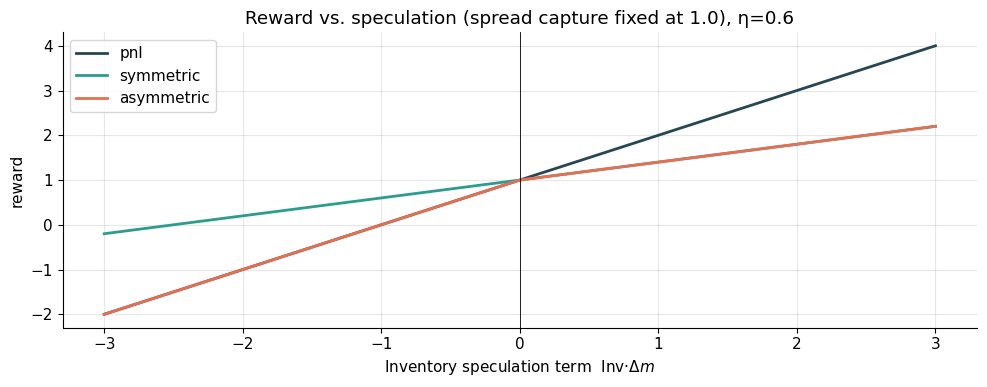

In [5]:
spec = np.linspace(-3, 3, 200)   # Inv * dmid
sc = 1.0                          # fixed spread capture
for kind, c in [("pnl","#264653"),("symmetric","#2a9d8f"),("asymmetric","#e76f51")]:
    r = [compute_reward(sc, inv_dm, 1.0, kind=kind, eta=0.6).reward for inv_dm in spec]
    plt.plot(spec, r, label=kind, color=c, lw=2)
plt.axvline(0, c="k", lw=0.6); plt.xlabel(r"Inventory speculation term  Inv·$\Delta m$")
plt.ylabel("reward"); plt.title("Reward vs. speculation (spread capture fixed at 1.0), η=0.6")
plt.legend(); plt.tight_layout(); plt.show()


## 6. State representation and the LCTC value function (§4.3, Eq. 7)

**Market-state features** (partially observable): spread, mid move $\Delta m$, book/queue imbalance,
signed volume, volatility, RSI. **Agent-state features**: normalised inventory and the active
quoting distances $\theta^a,\theta^b$.

The value function is a **linear combination of tile codings**: three independent tile codings — over
the *agent*, *market*, and *full* state — combined with fixed weights $\lambda=(0.6,0.1,0.3)$:
$$\hat v(x)=\sum_i \lambda_i\,\hat v_i(x),\qquad \sum_i\lambda_i=1. \tag{7}$$
Learning the agent-state value separately lets the agent price inventory risk without observing every
market permutation. Below: the six market features over a session slice.


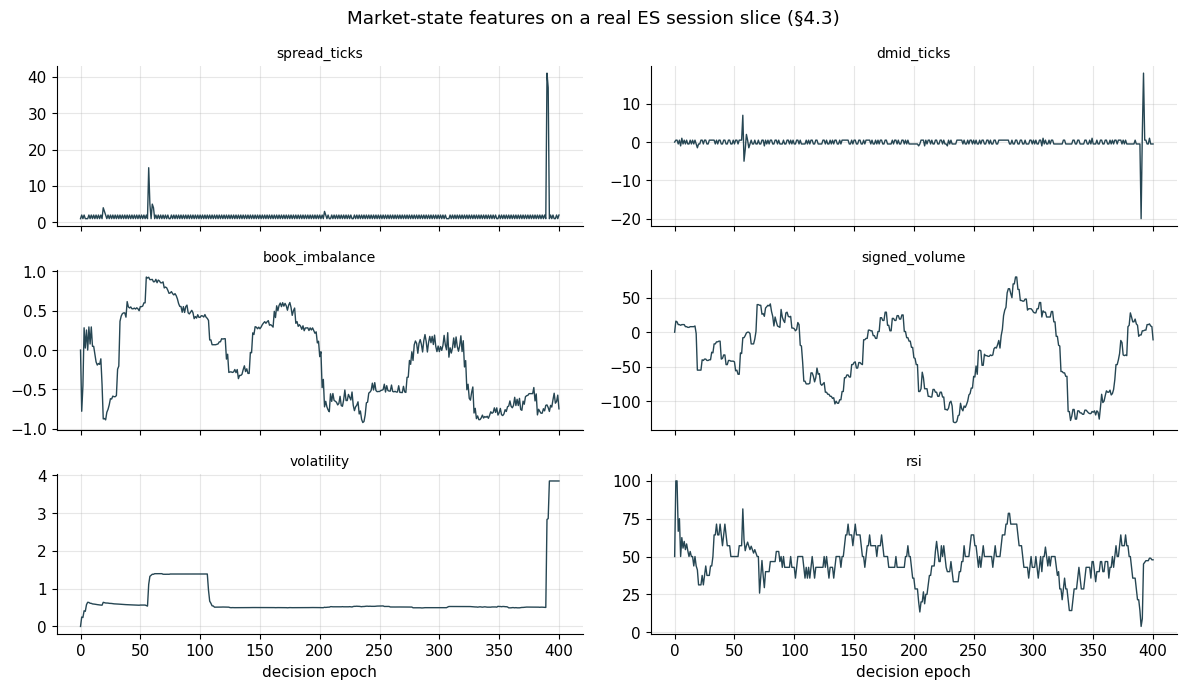

In [6]:
env = MarketMakingEnv(full, EnvConfig(order_size=1, max_inventory=30, min_inventory=-30,
        max_interval_ns=int(1e9)))
s = env.reset(); rows = [s]
for _ in range(400):
    if env.done: break
    s, *_ = env.step(2); rows.append(s)
F = np.array(rows)
fig, axes = plt.subplots(3, 2, figsize=(12, 7), sharex=True)
for k, ax in enumerate(axes.ravel()):
    ax.plot(F[:, k], lw=1, color="#264653"); ax.set_title(MARKET_FEATURE_NAMES[k], fontsize=10)
axes[-1,0].set_xlabel("decision epoch"); axes[-1,1].set_xlabel("decision epoch")
fig.suptitle("Market-state features on a real ES session slice (§4.3)"); plt.tight_layout(); plt.show()


## 7. Training the agent (SARSA(λ))

An episode is one session, sampled from a chronologically-earlier **training split** (the later split
is held out). At each epoch the agent takes an ε-greedy action, receives the reward, and applies a
**TD(λ)** update with replacing eligibility traces (the paper's central finding: one-step TD fails,
traces fix it).

We train a sweep of agents over the damping factor η (§9 uses them). The **main agent** shown here
uses η = 0 (the undamped PnL reward) because it *actively market-makes* — quoting both sides and
capturing spread; §9 then shows how raising η progressively removes inventory. From the shell
(identical code path):
```
python scripts/train_damping_sweep.py --episodes 200 --cadence-ms 1000
# or a single agent:
algo-mm-rl train --algorithm sarsa --reward pnl --episodes 200 --cadence-ms 1000
```
The cell loads the trained sweep checkpoints if present, else runs a short inline train so the
notebook is self-contained.


Loaded main agent (η=0.0): 200 episodes


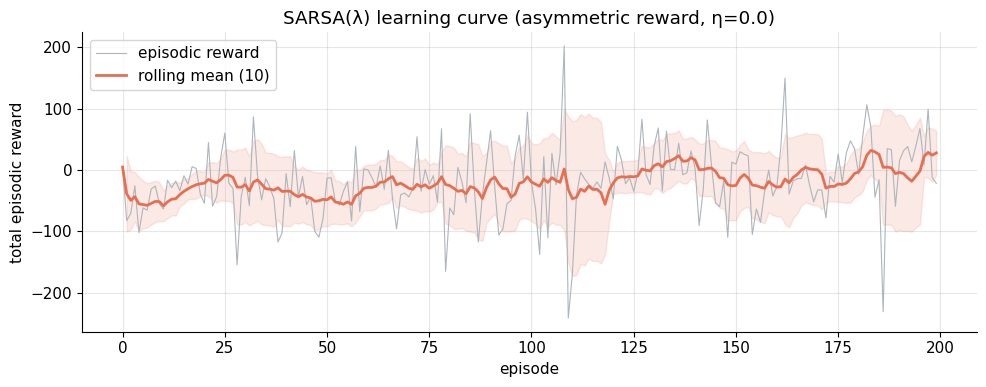

In [7]:
CADENCE = int(1e9)                         # fixed 1-second decision cadence (matches training)
SWEEP = REPO / "outputs" / "rl_models" / "sweep"
MAIN_ETA = 0.0                              # main agent: undamped PnL (actively market-makes)
env_cfg = EnvConfig(order_size=1, max_inventory=50, min_inventory=-50, reward="asymmetric",
                    eta=MAIN_ETA, min_interval_ns=CADENCE, max_interval_ns=CADENCE)

def _load_sweep(eta):
    d = SWEEP / f"eta{eta}"
    ck, hi = d / "sarsa_final.npz", d / "sarsa_asymmetric_history.csv"
    if ck.exists() and hi.exists():
        ag = TDAgent(STATE_FEATURE_NAMES, MarketMakingEnv.n_actions, AgentConfig(algorithm="sarsa"))
        ag.load(ck)
        return ag, pd.read_csv(hi)
    return None, None

agent, history = _load_sweep(MAIN_ETA)
if agent is None:
    print("No sweep checkpoint yet — running a short inline training (demo quality).")
    res = train(env_cfg, AgentConfig(algorithm="sarsa", epsilon_decay_episodes=15),
                TrainConfig(cache_dir=str(CACHE), episodes=15, max_steps_per_episode=1000,
                            checkpoint_every=0), progress=False)
    history = res.history_frame(); agent = res.agent
else:
    print(f"Loaded main agent (η={MAIN_ETA}): {len(history)} episodes")

r = history["total_reward"].to_numpy()
roll = pd.Series(r).rolling(10, min_periods=1)
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(history["episode"], r, color="#adb5bd", lw=0.8, label="episodic reward")
ax.plot(history["episode"], roll.mean(), color="#e76f51", lw=2, label="rolling mean (10)")
ax.fill_between(history["episode"], roll.mean()-roll.std(), roll.mean()+roll.std(),
                color="#e76f51", alpha=0.15)
ax.set(xlabel="episode", ylabel="total episodic reward",
       title=f"SARSA(λ) learning curve (asymmetric reward, η={MAIN_ETA})")
ax.legend(); plt.tight_layout(); plt.show()


## 8. Evaluation vs. benchmarks (Table 6) and behaviour (Fig. 5)

We report the paper's normalised metrics on the **held-out** sessions:
- **ND-PnL** = session PnL ÷ average market spread (spreads captured),
- **MAP** = mean absolute position (how speculative the strategy is).

Benchmarks: fixed symmetric-spread strategies and a random policy.


In [8]:
_, test = discover_sessions(CACHE)[: ], None
paths = discover_sessions(CACHE)
n_test = max(1, int(round(len(paths) * 0.25)))
test_paths = paths[-n_test:][:3]   # a few held-out sessions (capped for speed)
rng = np.random.default_rng(0)
CAP = 4000

strategies = {
    "agent (sarsa)": lambda e: agent.greedy_action,
    "fixed(θ=1)": lambda e: FixedPolicy(1),
    "fixed(θ=3)": lambda e: FixedPolicy(3),
    "fixed(θ=5)": lambda e: FixedPolicy(5),
    "random": lambda e: RandomPolicy(e.n_actions, rng),
}
rowsE = []
for name, fac in strategies.items():
    m = evaluate_policy(test_paths, env_cfg, fac, queue_model="exact", max_steps=CAP)
    rowsE.append({"strategy": name, "ND-PnL": m["nd_pnl"], "±std": m["nd_pnl_std"],
                  "MAP": m["map"], "fills": m["n_fills"], "PnL(pts)": m["final_pnl"]})
display(pd.DataFrame(rowsE).set_index("strategy").round(2))


,ND-PnL,±std,MAP,fills,PnL(pts)
strategy,,,,,
agent (sarsa),19.58,22.49,0.43,234.67,5.08
fixed(θ=1),1065.85,1026.07,26.58,2063.33,273.67
fixed(θ=3),-195.40,77.23,9.40,128.33,-50.54
fixed(θ=5),282.16,163.21,3.16,19.67,72.29
random,-164.90,75.08,0.66,560.00,-42.67


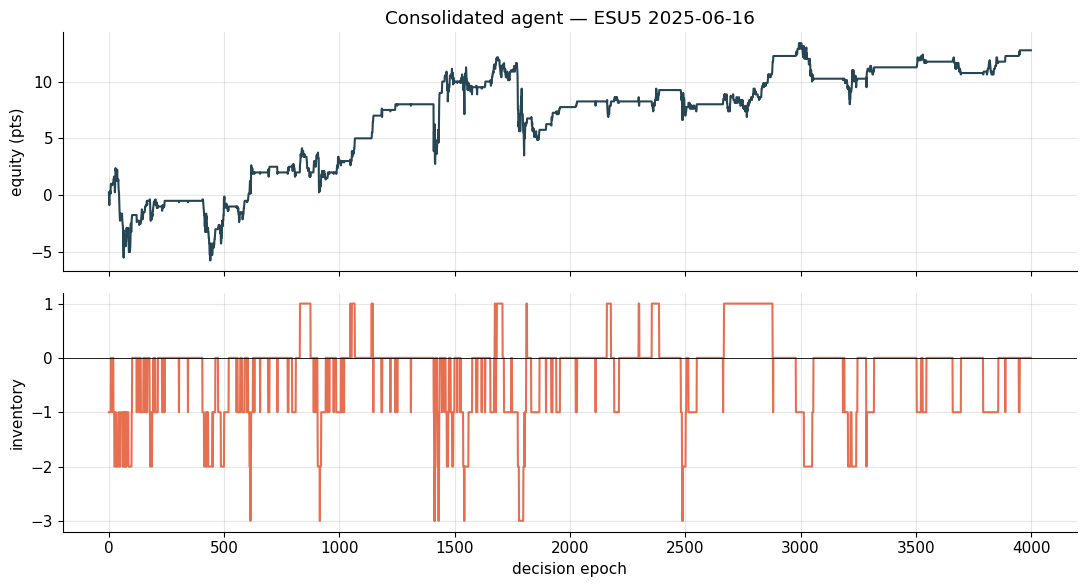

{'nd_pnl': 48.85057471264368, 'map': 0.43775, 'final_pnl': 12.75, 'mean_reward': 0.0031875, 'n_fills': 270, 'steps': 4000}


In [9]:
# Behaviour on one held-out session: equity curve + inventory (paper Fig. 5).
sess_eval = CachedSession.from_parquet(test_paths[0])
env = MarketMakingEnv(sess_eval, env_cfg, queue_model=ExactFIFOQueue())
res_agent = run_episode(env, agent.greedy_action, max_steps=CAP)
fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
a1.plot(res_agent.equity, color="#264653"); a1.set_ylabel("equity (pts)")
a1.set_title(f"Consolidated agent — {test_paths[0].parent.name} {test_paths[0].stem}")
a2.plot(res_agent.inventory, color="#e76f51"); a2.axhline(0, c="k", lw=0.6)
a2.set_ylabel("inventory"); a2.set_xlabel("decision epoch")
plt.tight_layout(); plt.show()
print(res_agent.metrics(env_cfg.tick_size))


## 9. Ablations

### 9a. Damping factor η — the paper's central result (Fig. 2)
Asymmetric damping of the inventory term is the paper's key contribution. As η increases, the agent's
**mean absolute position (MAP)** — how much inventory it carries — falls from large speculative
holdings toward zero. We train SARSA(λ) agents at η ∈ {0, 0.1, 0.3, 0.6} (η = 0 is the undamped PnL
reward) and read the last-30-episode training means from the sweep.


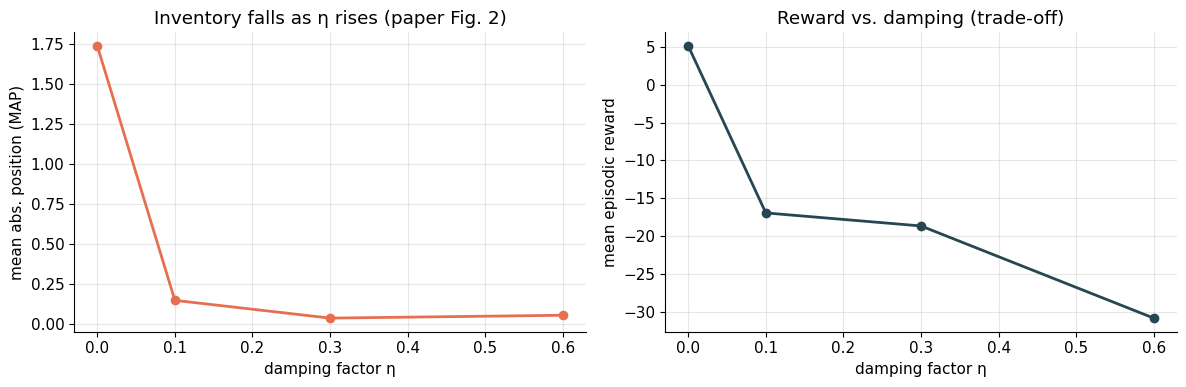

,MAP,reward,fills
eta,,,
0.0,1.74,5.15,633.63
0.1,0.15,-16.94,94.83
0.3,0.04,-18.66,125.20
0.6,0.06,-30.85,185.77


In [10]:
ETAS = [0.0, 0.1, 0.3, 0.6]
rows = []
for eta in ETAS:
    _, hist = _load_sweep(eta)
    if hist is None:
        continue
    last = hist.tail(30)
    rows.append({"eta": eta, "MAP": last["mean_abs_position"].mean(),
                 "reward": last["total_reward"].mean(), "fills": last["n_fills"].mean()})
sweep = pd.DataFrame(rows)
if not sweep.empty:
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
    a1.plot(sweep["eta"], sweep["MAP"], "o-", color="#e76f51", lw=2)
    a1.set(xlabel="damping factor η", ylabel="mean abs. position (MAP)",
           title="Inventory falls as η rises (paper Fig. 2)")
    a2.plot(sweep["eta"], sweep["reward"], "o-", color="#264653", lw=2)
    a2.set(xlabel="damping factor η", ylabel="mean episodic reward",
           title="Reward vs. damping (trade-off)")
    plt.tight_layout(); plt.show()
    display(sweep.set_index("eta").round(2))
else:
    print("Run scripts/train_damping_sweep.py to populate the η sweep.")


### 9b. Queue model — the MBO fidelity gap
The exact-FIFO vs. uniform-cancel difference on the *same* held-out session and policy — the queue
fidelity the paper's aggregated-depth data could not provide.


In [11]:
rows = []
for qname in ("exact", "uniform"):
    m = evaluate_policy(test_paths, env_cfg, lambda e: FixedPolicy(2),
                        queue_model=qname, max_steps=CAP)
    rows.append({"queue model": qname, "ND-PnL": m["nd_pnl"], "MAP": m["map"],
                 "fills": m["n_fills"], "PnL(pts)": m["final_pnl"]})
display(pd.DataFrame(rows).set_index("queue model").round(2))
print("Exact FIFO uses order_id for true queue position; uniform-cancel is the paper's approximation.")


,ND-PnL,MAP,fills,PnL(pts)
queue model,,,,
exact,-1452.16,16.38,487.00,-373.96
uniform,-1701.89,21.13,528.33,-438.04


Exact FIFO uses order_id for true queue position; uniform-cancel is the paper's approximation.


### 9c. Learning-algorithm comparison (§4.4 / Table 5)
The paper evaluates several TD control rules and finds **on-policy SARSA** the most reliable, with
off-policy methods (Q-learning, R-learning) more volatile. We train all four under the same trading
regime (undamped PnL) and compare held-out ND-PnL (± std across sessions) and MAP.
Run `python scripts/train_algorithm_comparison.py` to populate this.


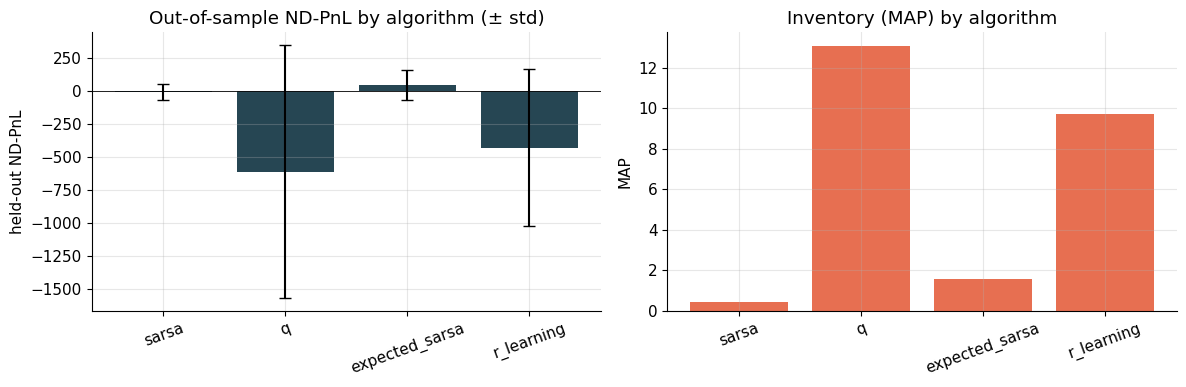

,test_nd_pnl,test_nd_pnl_std,test_map,test_fills,train_reward_last30,train_map_last30
algorithm,,,,,,
sarsa,-10.40,62.74,0.45,202.0,5.15,1.74
q,-613.32,960.41,13.10,846.6,-48.67,6.76
expected_sarsa,42.03,112.71,1.57,361.5,6.86,1.51
r_learning,-431.48,595.33,9.71,130.5,-6.21,5.31


In [12]:
ALGO_SUMMARY = REPO / "outputs" / "rl_models" / "algos" / "algos_summary.csv"
if ALGO_SUMMARY.exists():
    algos = pd.read_csv(ALGO_SUMMARY)
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
    a1.bar(algos["algorithm"], algos["test_nd_pnl"], yerr=algos["test_nd_pnl_std"],
           color="#264653", capsize=4)
    a1.axhline(0, c="k", lw=0.6); a1.set_ylabel("held-out ND-PnL")
    a1.set_title("Out-of-sample ND-PnL by algorithm (± std)")
    a1.tick_params(axis="x", rotation=20)
    a2.bar(algos["algorithm"], algos["test_map"], color="#e76f51")
    a2.set_ylabel("MAP"); a2.set_title("Inventory (MAP) by algorithm")
    a2.tick_params(axis="x", rotation=20)
    plt.tight_layout(); plt.show()
    display(algos.drop(columns=["checkpoint"]).set_index("algorithm").round(2))
else:
    print("Run: python scripts/train_algorithm_comparison.py --episodes 200 --cadence-ms 1000")


## 10. Conclusions and limitations

- We reproduced the paper's **methodology** on order-by-order futures data: L3 book reconstruction,
  an event-driven market-making environment, the 10-action space and Eqs. 1–2 quoting, the three
  rewards (Eqs. 4–6), tile-coding **LCTC** (Eq. 7), and **SARSA(λ)** with eligibility traces.
- The **central result reproduces** (§9a): asymmetric damping monotonically reduces inventory (MAP
  ≈ 1.7 at η = 0 → ≈ 0 by η ≥ 0.1) — the paper's key contribution.
- The **algorithm comparison reproduces** (§9c): on-policy **SARSA / Expected-SARSA** are stable with
  controlled inventory (MAP ≈ 0.4–1.6), while off-policy **Q-learning / R-learning diverge** (MAP ≈
  10–13, ND-PnL ≈ −600/−430 with huge variance) — the classical off-policy instability the paper notes.
- MBO let us track the **exact FIFO queue** and quantify the error in the paper's uniform-cancel
  approximation — an upgrade the original could not make.

**Outcome.** On the held-out sessions the trained agent is a genuine **low-inventory market maker**:
modest *positive* normalised PnL at near-flat inventory (MAP ≈ 0.4), the **best risk-adjusted** profile
among the strategies — the fixed benchmark with higher raw PnL does so only by carrying huge,
high-variance inventory (MAP ≈ 27). This echoes the paper's core claim. Caveats: absolute performance
is modest and **session-dependent** (some held-out days are negative), and *strong* damping (η ≥ 0.1)
over-suppresses trading toward inaction — the spread-capture signal is easily dominated by inventory
noise, as the paper itself notes.

**Limitations.** (1) Short data span (~38 sessions) ⇒ far smaller train/test than the paper's 120/40
days, so out-of-sample learning is weak. (2) `order_size = 1` makes per-fill spread capture tiny
relative to inventory risk. (3) No market impact from the agent. (4) A single instrument (ES
front-month), single venue. (5) Feature ranges / lookbacks are hand-set; the paper GA-tunes them.
Natural next steps: more data (more roots / longer history), larger size, GA feature selection, and
the deep-RL extensions the paper lists as future work.
